### **Projeto extensionista  do curso Tópicos de Big Data em Python**
- Faculdate Estacio de Sá RJ (Unesa)
- Aluno: José Roberto Duarte Hegendorne
- Matrícula: 202502214154
- Curso Presencial
- Professora: Simone Gama
- Período: 1ª semestre 2026
---

### **Dados do Sistema de Bilhetagem Eletrônica**

**URL dos dados analizados:** 
https://dadosabertos.rj.gov.br/dataset/setram_sbe

---


## **Repositório de dados baixados**
- https://dadosabertos.rj.gov.br/dataset/setram_sbe
**link do repósitorio do drive é** 
- https://drive.google.com/drive/folders/1486i6aBSUVuyrD6bISm0qYGZs-eIhK71?usp=sharing

*os arquivos são distribuidos com a movimentação diaria do bilhete unico, fazer o carregamento disso, em grandes periodos , requer um hardware com mais recursos*

---



## **Dicionario de Dados dos arquivos originais:** 
#### Cartão Hash:** 
  - Sequência única de caracteres gerada a partir do Nº Cartão.
  
#### Data da Transação:
#### Data e hora do processamento da transação
#### Data do Processamento
#### Descrição da Aplicação

   **Código da aplicação do cartão**
   - 100 - Expresso
   - 400 - Vale-transporte, 
   - 450 - Empresarial, 
   - 820 - Gratuidade de Morador de Paquetá/Ilha Grande, 
   - 80 QRCode Unitário
    
#### Linha
  - Número e nome da Linha.
#### Nº Carro
  - Número da estação ou do carro onde a transação foi realizada.
#### Nº Cartão
  - Número externo do cartão do usuário. Informação anonimizada para atender a LGPD, conforme exemplo a seguir: 1091xxxxxx713.
#### Nº Validador
  - Número do validador utilizado na transação.
#### Operadora
  -  Nome da Operadora de transporte. 
      _Informação anonimizada para as Vans para atender a LGPD, conforme exemplo a seguir: VAN560001-LUISA MAxxxxxxxx_
#### Sentido
  - Código do sentido da linha (0 - não informado, 1 - ida, 2 - volta).
#### Sindicato
  - Nome do sindicato
#### Vl Linha
  - Valor da linha da operadora de transporte.
#### Vl Subsídio
  - Valor do subsídio.
#### Vl Trans
  - Valor descontado no cartão do usuário.
 

**Variaveis declaradas:**
  - Pd - pandas 
  - Bu_total - data frame que recebe o CSV sem tratamento
  - Bu - data frame com Csv tratado
  - colunas - lista os campos que irei utilizar 

 **Bibliotecas Python:** 
 - Pandas,
 - Numpy,
 - MatplotLib,
 - Sklearn,
 - seaborn.
---
  **Funções** 
  - *Carrega_dados* - tem como objetivo  facilitar o desenvolvimento limitando a tabela pelo numero de linhas.
---



**Informações importantes sobre a base de dados de bilhetagem eletrônica**   

O governo do estado do rio de janeiro cadastra suas informações quantitativas de forma misturada em 2 perfis distintos.

1º.  Há passageiros que pagam integralmente a passagem  no formato  1:1 (1 bilhetagem = 1 pagamento) sem elegibilidade para subsidios.
      

2º   Há passageiros que são Subsidiados pelo Estado. 


para fazer uma regressão linear conclusiva, precisei separar esses dois grupos em 2 Dataframes e farei as análises de forma distintas para cada grupo.


DataFrames  quantitativos não elegiveis para integração
 80-QR CODE UNITÁRIO, 450-CARTÃO EMPRESARIAL


DataFrames  quantitativos elegiveis para integração 
  100-EXPRESSO	forte presença de subsídio
  400-VALE TRANSPORTE CONVENCIONAL	comportamento híbrido




Importando as bibliotecas

In [149]:
import pandas as Pd                                         # Biblioteca para manipulação de dados              
import numpy as np                                          # Biblioteca para cálculos numéricos
import matplotlib.pyplot as plt                             # Biblioteca para gráficos
import seaborn as sns                                        # Biblioteca para gráficos estatísticos
sns.set(style="whitegrid")
from sklearn.linear_model import LinearRegression            # Biblioteca para regressão linear
from sklearn.model_selection import train_test_split         # Biblioteca para divisão de dados
from sklearn.metrics import mean_squared_error, r2_score     # Biblioteca para métricas de regressão


Fazendo Carregamento da Base CSV do Bilhete unico

In [150]:
# Utilizando a função para carregar os dados com um número específico de linhas para facilitar o desenvolvimento e testes iniciais
#Diretorio = "D:\\python\\facul\\"
Diretorio = "I:\\python\\facul\\"
nome_arquivo = "TRANSACAO_BE_PUBLICO_2026_03_22"

def Carregar_Dados(quantidade_linhas=None, arquivo=r""):
  try:
    dados_df =  Pd.read_csv(arquivo, encoding='utf-8-sig', sep=';', nrows=quantidade_linhas)
    return dados_df
  except Exception:
    print(f"Erro ao carregar os dados")
    return None
  
Bu_total = Carregar_Dados(None, Diretorio + nome_arquivo + ".csv") 


Estou estruturando os campos do arquivo CSV à serem tratados,
Removi rash e o numero do cartão do passageiro porque eles esconderam o numero real com caracteres X Nº  2024XXXXX3128     

In [151]:
# Listando os campos que serão utilizados para a análise, garantindo que o dataframe Bu seja uma cópia do dataframe Bu_total, evitando alterações indesejadas no dataframe original.
colunas = [
    "Data da Transação",
    "Descrição da Aplicação",
    "Sentido",
    "Nº Validador",
    "Sindicato",
    "Operadora",
    "Linha",
    "Nº Carro",
    "Vl Linha",
    "Vl Trans",
    "Vl Subsídio"
]
Bu = Bu_total[colunas].copy()
#garantindo que o dataframe Bu seja uma cópia do dataframe Bu_total, evitando alterações indesejadas no dataframe original.  

### TRATAMENTO DOS DADOS 
##### ----------------------------------------------------------


###  Renomeando as colunas das tabelas, Removendo espaços , caracteres especiais  utilizando .rename (columns={"xx":"yy"}) 

In [152]:
Bu.rename(columns={"Data do Processamento": "Data_do_Processamento",    
    "Data da Transação":"Data_da_Transacao",
    "Descrição da Aplicação":"Descricao_da_Aplicacao",
    "Nº Validador":"N_Validador",
    "Nº Carro": "N_Carro",
    "Vl Linha":"Vl_Linha",
    "Vl Trans":"Vl_Trans",
    "Vl Subsídio":"Vl_Subsidio"}, inplace=True)    # inplace=True é necessario para manter salvo as mudanças no dataframe Bu, sem a necessidade de criar um novo dataframe para armazenar as mudanças.

#------------------------------------------------------
#exibindo as inforamações da tabela para verificar a alteração dos nomes das colunas e o tipo de dados de cada coluna, além de verificar se há valores nulos ou não.
Bu.info()

<class 'pandas.DataFrame'>
RangeIndex: 539068 entries, 0 to 539067
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Data_da_Transacao       539068 non-null  str    
 1   Descricao_da_Aplicacao  539068 non-null  str    
 2   Sentido                 531960 non-null  float64
 3   N_Validador             539068 non-null  int64  
 4   Sindicato               539068 non-null  str    
 5   Operadora               539068 non-null  str    
 6   Linha                   539068 non-null  str    
 7   N_Carro                 539068 non-null  int64  
 8   Vl_Linha                539068 non-null  str    
 9   Vl_Trans                539068 non-null  str    
 10  Vl_Subsidio             270140 non-null  str    
dtypes: float64(1), int64(2), str(8)
memory usage: 45.2 MB


### Tratando o Campo "Sentido"

### Sentido:
  -      Código do sentido da linha (0 - não informado, 1 - ida, 2 - volta).
  -      Tudo que estiver vazio(NaN) receberá 0
  -      Convertendo o campo em Inteiro pois esta como float .astype(int)
  -      Precisei arredondar para converter usando .round()


In [153]:
Bu["Sentido"] = Bu["Sentido"].fillna(0) # a função filna do panda preenche o vazio com 0 (zero)
Bu["Sentido"] = Bu["Sentido"].round().astype(int) # arredondando com round e convertendo para inteiro
Bu["Sentido"] = Bu["Sentido"].map({0: "Desconecido", 1: "Ida", 2: "Volta"}) # mapeando os valores para as 

### Tratando valor do subsidio   "Vl Subsídio"  porque há valores vazios (NaN), fiz remocao de strings, ponto pra caracterizar milhar e substituir , por . para converter em float


In [154]:
Bu["Vl_Subsidio"] = Bu["Vl_Subsidio"].fillna(0)  # 
Bu['Vl_Subsidio'] = (
    Bu['Vl_Subsidio']
    .astype(str)
    .str.replace('R$', '', regex=False)
    .str.replace('.', '', regex=False)   # remove separador de milhar
    .str.replace(',', '.', regex=False)  # converte decimal brasileiro
    .str.strip().astype(float)
)

## Tratando os campos que contém data. pois o formato esta em string
mudou o padrão de XX / XX / XXXX para xx-xx-xxxx  

In [155]:
# tratando campo de data colocando os dias como primeiro(dayfirst)
Bu["Data_da_Transacao"] = Pd.to_datetime(Bu["Data_da_Transacao"],dayfirst=True,errors='coerce') #coerce joga valores invalidos para NaT (Not a Time)
# a função to_datetime do pandas converte a coluna de data para o formato datetime, com dayfirst=True para garantir que o dia seja interpretado como o primeiro elemento da data, e errors='coerce' para lidar com valores inválidos, convertendo-os para NaT (Not a Time).


# trocando valores  de ","   para "." e convertendo para float
Bu["Vl_Linha"] = Bu["Vl_Linha"].str.replace(",", ".").astype(float)
Bu["Vl_Trans"] = Bu["Vl_Trans"].str.replace(",", ".").astype(float)

Bu.info()

<class 'pandas.DataFrame'>
RangeIndex: 539068 entries, 0 to 539067
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Data_da_Transacao       539068 non-null  datetime64[us]
 1   Descricao_da_Aplicacao  539068 non-null  str           
 2   Sentido                 539068 non-null  str           
 3   N_Validador             539068 non-null  int64         
 4   Sindicato               539068 non-null  str           
 5   Operadora               539068 non-null  str           
 6   Linha                   539068 non-null  str           
 7   N_Carro                 539068 non-null  int64         
 8   Vl_Linha                539068 non-null  float64       
 9   Vl_Trans                539068 non-null  float64       
 10  Vl_Subsidio             539068 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(5)
memory usage: 45.2 MB


Limpando os campos vazio dos campos dos campos que são string

Descricao_da_Aplicacao , Operadora , Linha, Sindicato

In [156]:
Bu["Descricao_da_Aplicacao"] = Bu["Descricao_da_Aplicacao"].str.strip()
Bu["Operadora"] = Bu["Operadora"].str.strip()
Bu["Linha"] = Bu["Linha"].str.strip()
Bu["Sindicato"] = Bu["Sindicato"].str.strip()

In [157]:
# Exibe informações gerais da base
print('\n===== INFORMAÇÕES DA BASE =====')
print(Bu.info())


===== INFORMAÇÕES DA BASE =====
<class 'pandas.DataFrame'>
RangeIndex: 539068 entries, 0 to 539067
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Data_da_Transacao       539068 non-null  datetime64[us]
 1   Descricao_da_Aplicacao  539068 non-null  str           
 2   Sentido                 539068 non-null  str           
 3   N_Validador             539068 non-null  int64         
 4   Sindicato               539068 non-null  str           
 5   Operadora               539068 non-null  str           
 6   Linha                   539068 non-null  str           
 7   N_Carro                 539068 non-null  int64         
 8   Vl_Linha                539068 non-null  float64       
 9   Vl_Trans                539068 non-null  float64       
 10  Vl_Subsidio             539068 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(5)
memory usage: 45.2

In [158]:
# VERIFICAÇÃO DE DADOS AINDA NÃO TRATADOS
# ============================================================
# Verifica valores nulos
print('\n===== VALORES NULOS =====')
Bu.isnull().sum()


===== VALORES NULOS =====


Data_da_Transacao         0
Descricao_da_Aplicacao    0
Sentido                   0
N_Validador               0
Sindicato                 0
Operadora                 0
Linha                     0
N_Carro                   0
Vl_Linha                  0
Vl_Trans                  0
Vl_Subsidio               0
dtype: int64

In [159]:
# Verifica registros duplicados
print('\n===== REGISTROS DUPLICADOS =====')
print(Bu.duplicated().sum())


===== REGISTROS DUPLICADOS =====
88746


In [160]:
# Verifica tipos de dados
print('\n===== TIPOS DAS COLUNAS =====')
print(Bu.dtypes)
print('\n===== INFORMAÇÕES DA BASE =====')
print(Bu.info())


===== TIPOS DAS COLUNAS =====
Data_da_Transacao         datetime64[us]
Descricao_da_Aplicacao               str
Sentido                              str
N_Validador                        int64
Sindicato                            str
Operadora                            str
Linha                                str
N_Carro                            int64
Vl_Linha                         float64
Vl_Trans                         float64
Vl_Subsidio                      float64
dtype: object

===== INFORMAÇÕES DA BASE =====
<class 'pandas.DataFrame'>
RangeIndex: 539068 entries, 0 to 539067
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Data_da_Transacao       539068 non-null  datetime64[us]
 1   Descricao_da_Aplicacao  539068 non-null  str           
 2   Sentido                 539068 non-null  str           
 3   N_Validador             539068 non-null  int64         
 4   

Gerando os arquivos de backup sem dados removidos

In [ ]:
Bu_backup = Bu.copy()  # backup para comparação
Bu_backup.to_csv(Diretorio +"bu_backup.csv", sep=';', index=False, encoding='utf-8-sig')  

Removendo dados irrelevantes para analise pois são passageiros com valor quantitativo 0.

In [ ]:
Bu = Bu[
    Bu["Descricao_da_Aplicacao"] != "820-BARCAS MORADOR"
]

Resultado da Remoção

In [ ]:
print("Total atual de registros: ", Bu.shape[0], "\nTotal de registros com valor de linha menor que R$:1,0: ", (Bu['Vl_Linha'] < 1).sum(), "\nPercentual de registros com valor de linha menor que 1: ", (Bu['Vl_Linha'] < 1).mean() * 100, "%")

print("Quantidade de registros com valor de linha menor que 1: ", (Bu['Vl_Linha'] < 1).sum())

print("Removi os registros com valor de linha menor que R$:1,0, totalizando: ", (Bu['Vl_Linha'] < 1).sum(), " registros removidos.")

Total atual de registros:  99998 
Total de registros com valor de linha menor que R$:1,0:  4 
Percentual de registros com valor de linha menor que 1:  0.004000080001600032 %
Quantidade de registros com valor de linha menor que 1:  4
Removi os registros com valor de linha menor que R$:1,0, totalizando:  4  registros removidos.


Salvando Banco de Dados tratado.

In [ ]:
Bu.to_csv( Diretorio + "dados_tratados_Bu.csv", sep=';', index=False, encoding='utf-8-sig')# encoding='utf-8-sig' garante a compatibilidade com caracteres acentuados, evitando problemas de codificação ao abrir o arquivo em diferentes sistemas operacionais ou softwares.

print("Total atual de registros: ", Bu.shape[0])

Total atual de registros:  99998


**Criando os Grupos em Elegiveis e não elegives"

## Fim do tratamento.
         ------------------------------------

In [ ]:
print("Dimensão dos dados do bilhete unico:")
shape_linha, shape_coluna = Bu.shape # total de registros e total de colunas do dataframe Bu
print(f"No momento temos {shape_linha} Linhas,  e  {shape_coluna} Colunas")


Dimensão dos dados do bilhete unico:
No momento temos 99998 Linhas,  e  11 Colunas


# 1) Análise descritiva da base de dados"

In [ ]:
# Informações Gerais.
print("=== 1. INFORMAÇÕES GERAIS ===")
print(Bu.shape)
print('\n')
print(f"Número de linhas (transações): {len(Bu):,}")
print(f"Número de colunas: {len(Bu.columns)}")
print('\n')
print("\nTipos de dados:")
print(Bu.dtypes)


=== 1. INFORMAÇÕES GERAIS ===
(99998, 11)


Número de linhas (transações): 99,998
Número de colunas: 11



Tipos de dados:
Data_da_Transacao         datetime64[us]
Descricao_da_Aplicacao               str
Sentido                              str
N_Validador                        int64
Sindicato                            str
Operadora                            str
Linha                                str
N_Carro                            int64
Vl_Linha                         float64
Vl_Trans                         float64
Vl_Subsidio                      float64
dtype: object



=== 2. VARIÁVEIS CATEGÓRICAS (Qualitativas) ===

Descricao_da_Aplicacao: 3 categorias únicas

        Descricao_da_Aplicacao
400-VALE TRANSPORTE CONVENCIONAL    92662
80-QR CODE UNITÁRIO                  7108
450-CARTÃO EMPRESARIAL                228
Name: count, dtype: int64


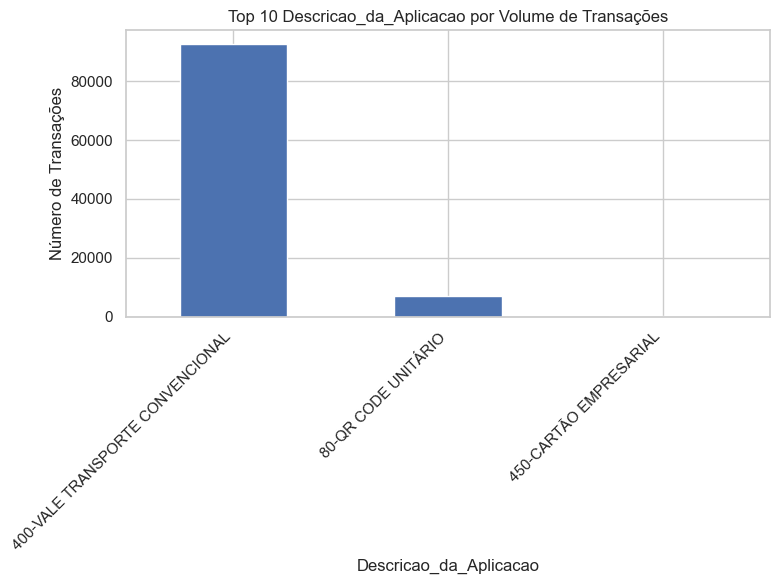

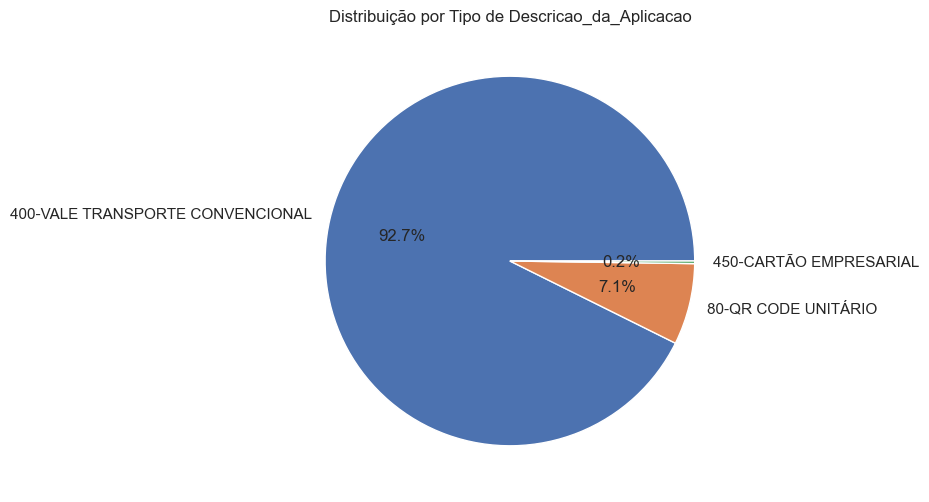


Sindicato: 11 categorias únicas

        Sindicato
METRÔ RIO               32013
TRANSONIBUS             25928
SETRERJ                 12629
VANS INTERMUNICIPAIS     9637
SETRANSDUC               8324
SUPERVIA                 5621
BARCAS                   4273
SINTERJ                  1389
RIO ÔNIBUS                147
SETRANSOL                  31
Name: count, dtype: int64


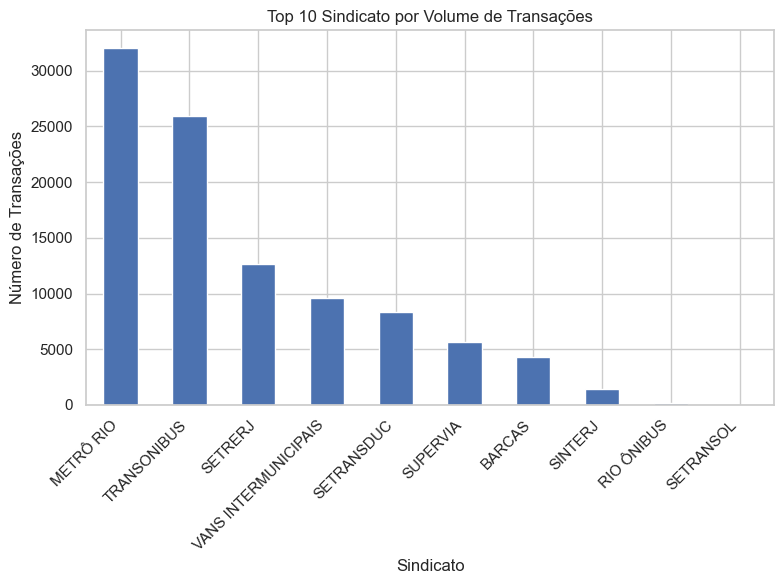

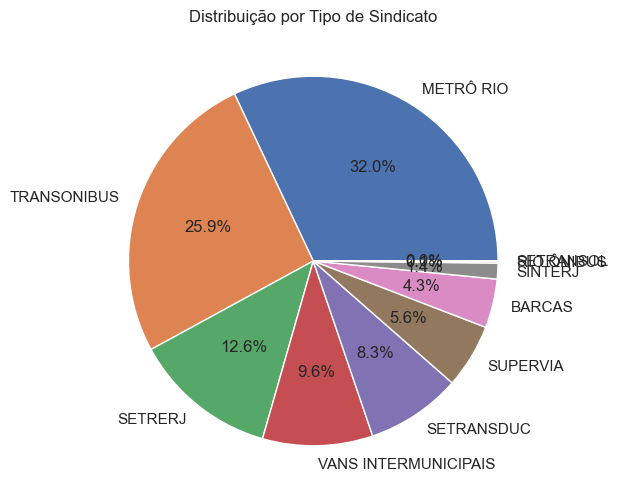


Operadora: 424 categorias únicas

        Operadora
Concessao Metroviaria do Rio de Janeiro S. A.    32013
Empresa de Transportes Flores Ltda                5623
Supervia Conc. Transp. Ferroviaria S.A.           5621
Transportes Santo Antônio Ltda                    4735
Barcas Rio                                        4273
Rio Ita Ltda                                      2620
Auto Ônibus Fagundes Ltda                         2125
Auto Viação Vera Cruz Ltda                        2102
Viação Nossa Senhora da Penha Ltda                1793
Auto Viação Reginas                               1722
Name: count, dtype: int64


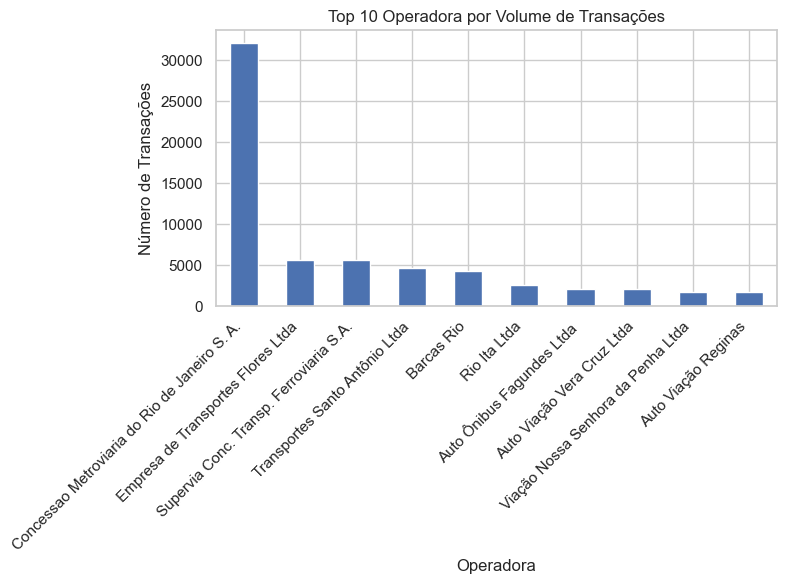

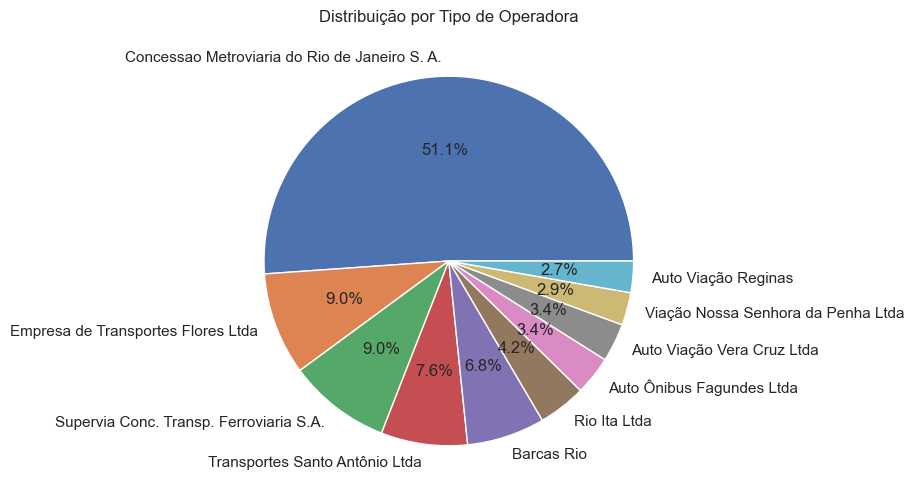


Linha: 687 categorias únicas

        Linha
L2 CNO - Estaçao Cidade Nova - metrô            5866
L1 CTR - Estação Central - Metrô                3630
L2 PVN - Estação Pavuna - Metrô                 3287
PXV-NIT - PRAÇA XV X ARARIBOIA                  2535
PXV-PQ - PRAÇAXV X PAQUETA                      1699
L1 BTF - Estação Botafogo - Metrô               1595
L4 JOC - Estação Jardim Oceânico                1302
128013 - NOVA IGUAÇU - XEREM                    1216
R1CBL - ESTAÇÃO CENTRAL DO BRASIL - SUPERVIA    1031
L1 SCP - Estação Siqueira Campos - Metrô         967
Name: count, dtype: int64


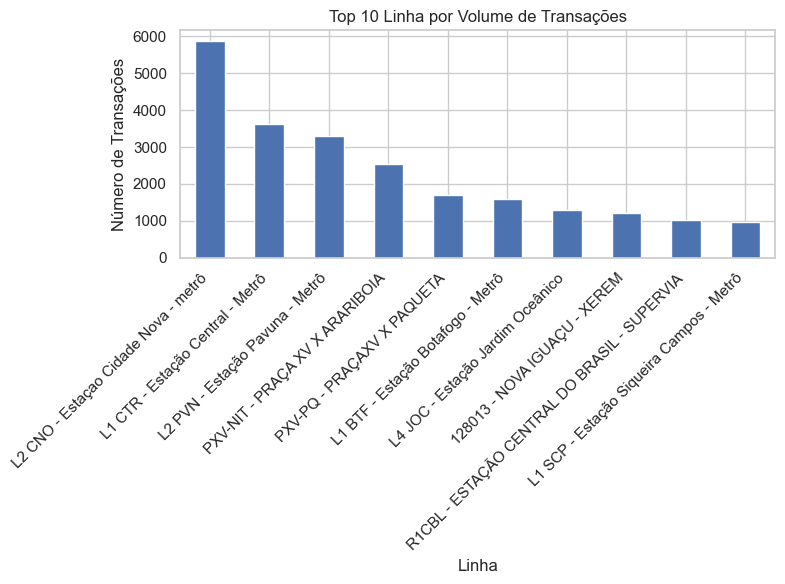

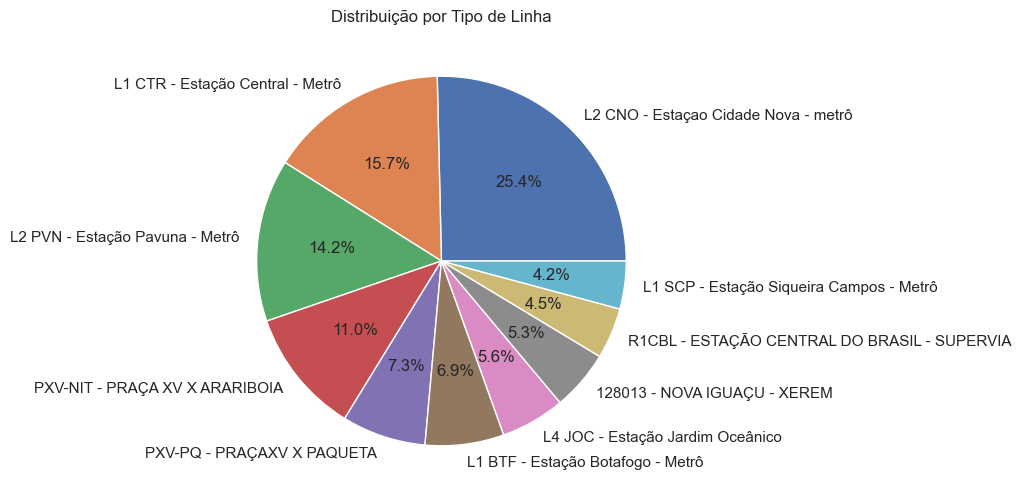

In [ ]:
print("\n=== 2. VARIÁVEIS CATEGÓRICAS (Qualitativas) ===")

categori_cal_cols = ['Descricao_da_Aplicacao', 'Sindicato', 'Operadora', 'Linha']

for col in categori_cal_cols:
    print(f"\n{col}: {Bu[col].nunique()} categorias únicas\n")
    print(' ' * 7, Bu[col].value_counts().head(10))

    plt.figure(figsize=(8, 6))    
    Bu[f'{col}'].value_counts().head(10).plot(kind='bar')
    plt.title(f'Top 10 {col} por Volume de Transações')
    plt.ylabel('Número de Transações')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout() #ajusta automaticamente o layout
    plt.show()
    plt.figure(figsize=(8, 6))
    Bu[f'{col}'].value_counts().head(10).plot(kind='pie', autopct='%1.1f%%')
    plt.title(f'Distribuição por Tipo de {col}')
    plt.ylabel('')
    plt.show()
    
    
    



Análise Descritiva quantitativa.

Para isso preciso dividir em dois grupos.  

os que recebem subsidio e os que não recebem

---

**Criando os grupos**

In [ ]:
G_Nao_elegiveis = [
    "80-QR CODE UNITÁRIO",
    "450-CARTÃO EMPRESARIAL"
]

G_Elegiveis = [
    "100-EXPRESSO",
    "400-VALE TRANSPORTE CONVENCIONAL"
]

Bu_nao_elegiveis = Bu[Bu["Descricao_da_Aplicacao"].isin(G_Nao_elegiveis)].copy()  # Grupo A - Não elegíveis
Bu_elegiveis = Bu[Bu["Descricao_da_Aplicacao"].isin(G_Elegiveis)].copy()  # Grupo B - Elegíveis

# Bunao_elegiveis.info()
# Bu_elegiveis.info()

Função de análise descritiva

In [ ]:
def analise_descritiva(dframe, nome):

 print(f"\n{'='*45}")
 print(f"{' '*7}ANÁLISE DESCRITIVA - {nome}")
 print(f"{'='*45}")

 print(dframe[[
  "Vl_Linha",
  "Vl_Trans",
  "Vl_Subsidio"
 ]].describe().round(2))

analise_descritiva(Bu_nao_elegiveis, "NÃO ELEGIVEIS")
analise_descritiva(Bu_elegiveis, "ELEGIVEIS")




       ANÁLISE DESCRITIVA - NÃO ELEGIVEIS
       Vl_Linha  Vl_Trans  Vl_Subsidio
count   7336.00   7336.00       7336.0
mean       6.72      6.72          0.0
std        1.70      1.70          0.0
min        5.00      5.00          0.0
25%        5.00      5.00          0.0
50%        7.90      7.90          0.0
75%        7.90      7.90          0.0
max       57.00     57.00          0.0

       ANÁLISE DESCRITIVA - ELEGIVEIS
       Vl_Linha  Vl_Trans  Vl_Subsidio
count  92662.00  92662.00     92662.00
mean       9.91      7.12         2.78
std        6.30      6.33         3.76
min        0.27      0.00         0.00
25%        7.10      5.00         0.00
50%        7.90      6.70         2.15
75%       10.40      7.90         3.95
max      199.78    199.78        25.15


**Distribuição de Frequência**

Historiograma

Grafico de Histograma para os dados do grupo:  NÃO ELEGIVEIS Para Bilhete Unico


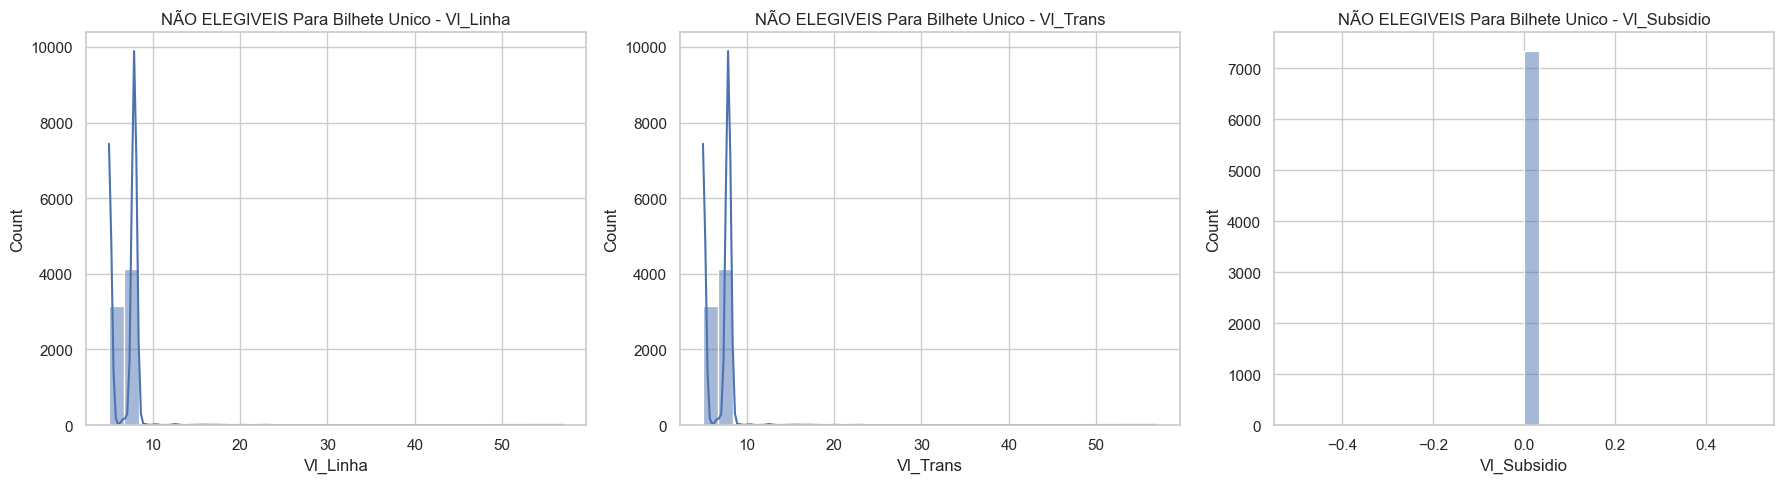

Grafico de Histograma para os dados do grupo:  ELEGIVEIS Para Bilhete Unico


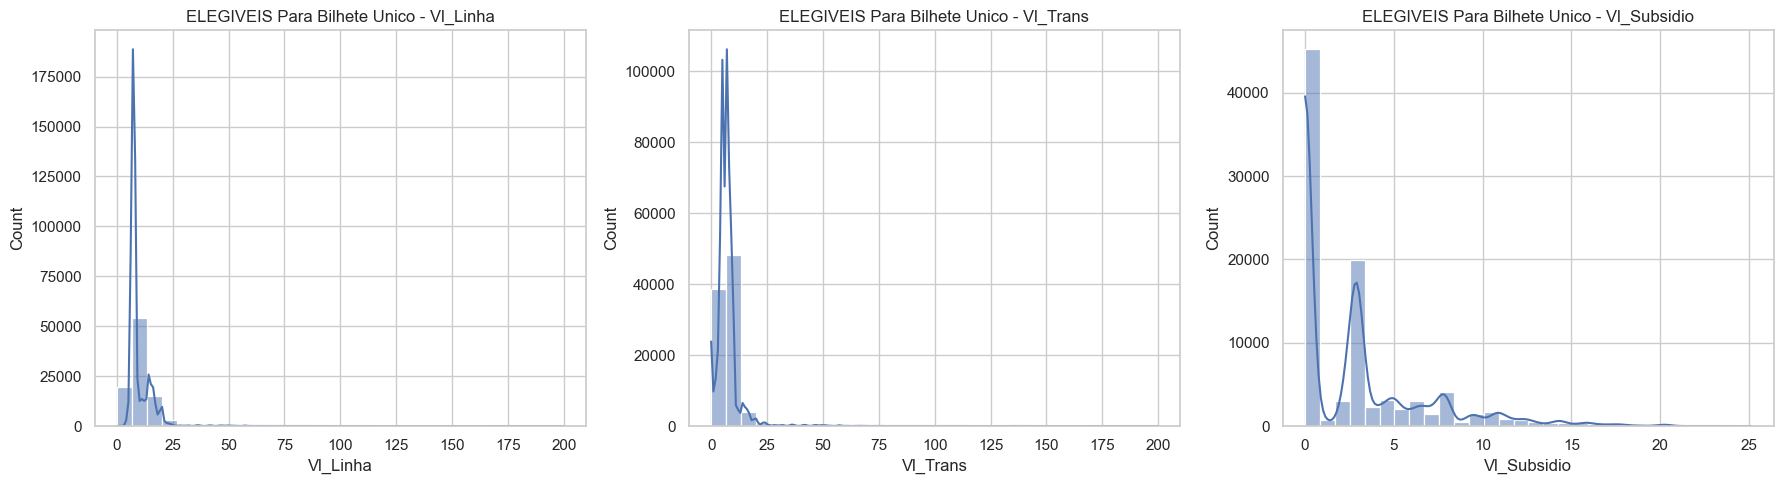

In [ ]:
def histogramas(dframe, nome):

 fig, axes = plt.subplots(1, 3, figsize=(18,5))

 colunas = [
  "Vl_Linha",
  "Vl_Trans",
  "Vl_Subsidio"
 ]
 print("Grafico de Histograma para os dados do grupo: ", nome)

 for i, col in enumerate(colunas):

  sns.histplot(
   dframe[col],
   bins=30,
   kde=True,
   ax=axes[i]
  )

  axes[i].set_title(f"{nome} - {col}")

 plt.tight_layout()
 plt.show()
 
histogramas(Bu_nao_elegiveis,"NÃO ELEGIVEIS Para Bilhete Unico")
histogramas(Bu_elegiveis,"ELEGIVEIS Para Bilhete Unico")

BoxPlot Para Outliers

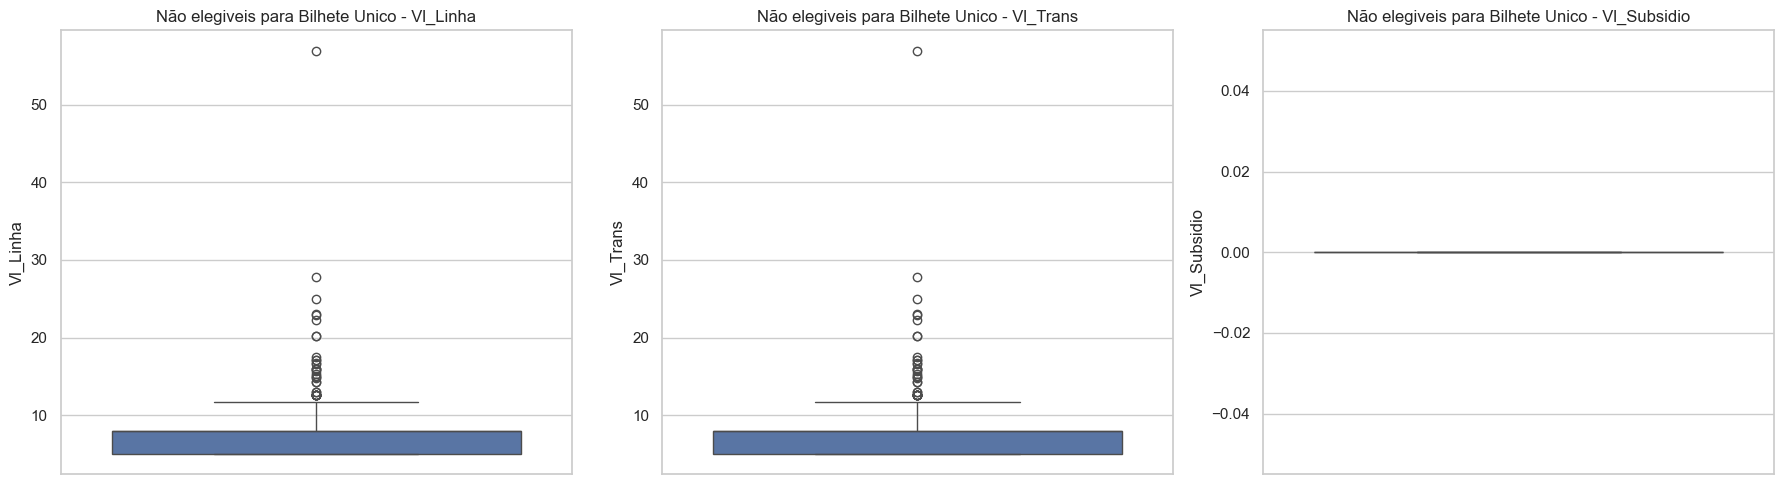

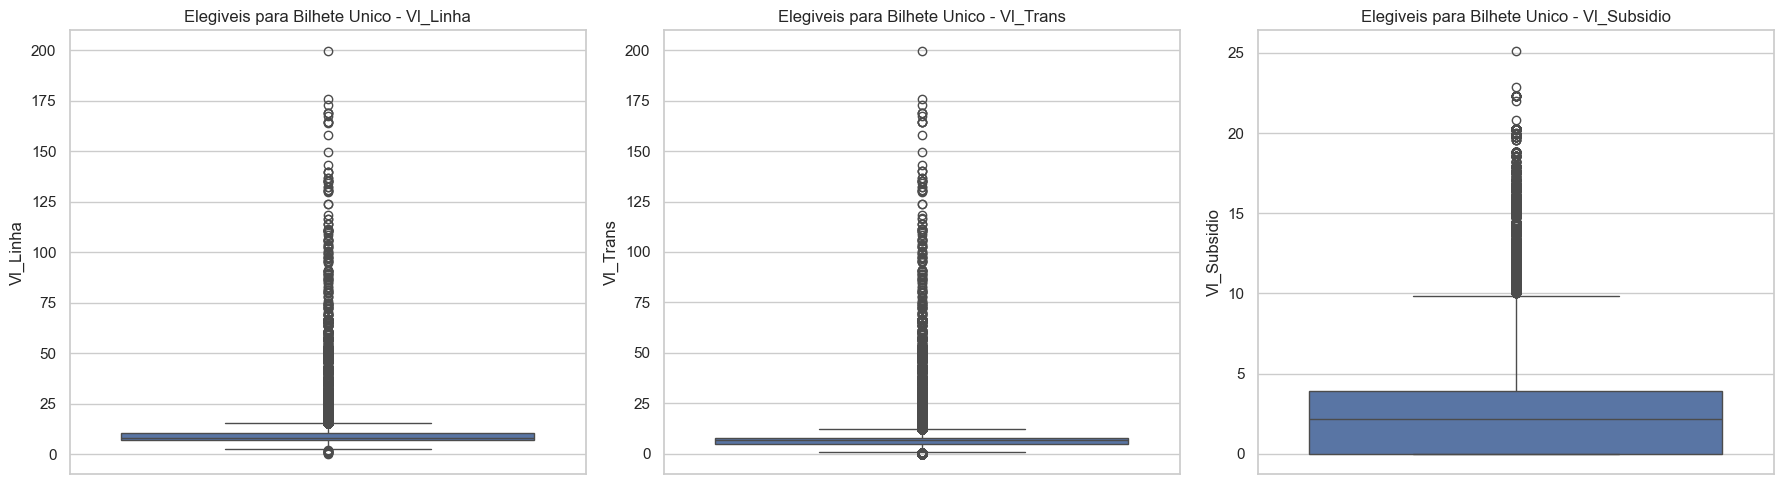

In [ ]:
def boxplots(dframe, nome):

    fig, axes = plt.subplots(1,3, figsize=(18,5))

    colunas = [
        "Vl Linha",
        "Vl Trans",
        "Vl Subsídio"
    ]

    for i, col in enumerate(colunas):

        sns.boxplot(
            y=dframe[col],
            ax=axes[i]
        )

        axes[i].set_title(f"{nome} - {col}")

    plt.tight_layout()
    plt.show()
def boxplots(dframe, nome): 
 fig, axes = plt.subplots(1, 3, figsize=(18, 5))

 colunas = [
  "Vl_Linha",
  "Vl_Trans",
  "Vl_Subsidio"
 ]

 for i, col in enumerate(colunas):
  sns.boxplot(
   y=dframe[col],
   ax=axes[i]
  )
  axes[i].set_title(f"{nome} - {col}")

 plt.tight_layout()
 plt.show()

boxplots(Bu_nao_elegiveis, "Não elegiveis para Bilhete Unico")
boxplots(Bu_elegiveis, "Elegiveis para Bilhete Unico")



Identificação de Outliers (IQR)

In [ ]:
def detectar_outliers(df, coluna):

    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    outliers = df[
        (df[coluna] < limite_inf) |
        (df[coluna] > limite_sup)
    ]

    return outliers


outliers_A = detectar_outliers(Bu_nao_elegiveis, "Vl_Trans")
outliers_B = detectar_outliers(Bu_elegiveis, "Vl_Trans")

print("Outliers Grupo Não elegiveis:", len(outliers_A))
print("Outliers Grupo Elegiveis:", len(outliers_B))


Outliers Grupo Não elegiveis: 35
Outliers Grupo Elegiveis: 11925


---
**Regressão Linear Simples**

Função da Regressão




REGRESSÃO - Não elegiveis para Bilhete Unico
Coeficiente Angular: 0.0
Intercepto: 0.0
R²: 1.0


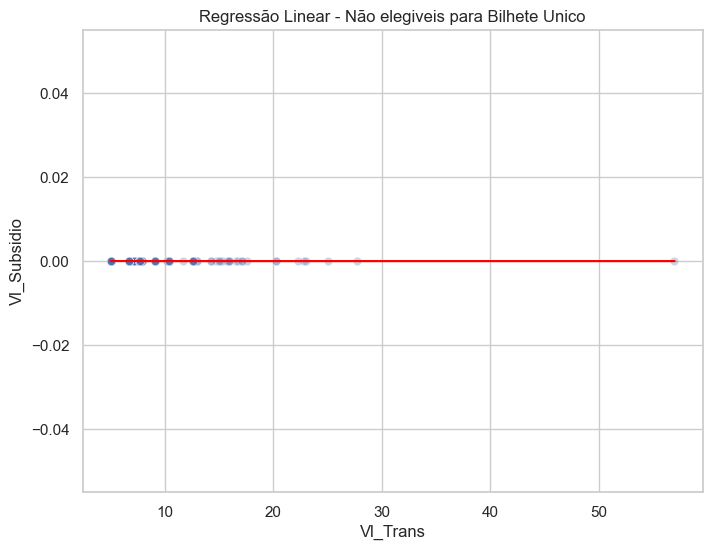


REGRESSÃO - Elegiveis para Bilhete Unico
Coeficiente Angular: -0.17952129208936843
Intercepto: 4.054549962524687
R²: 0.09153708583358144


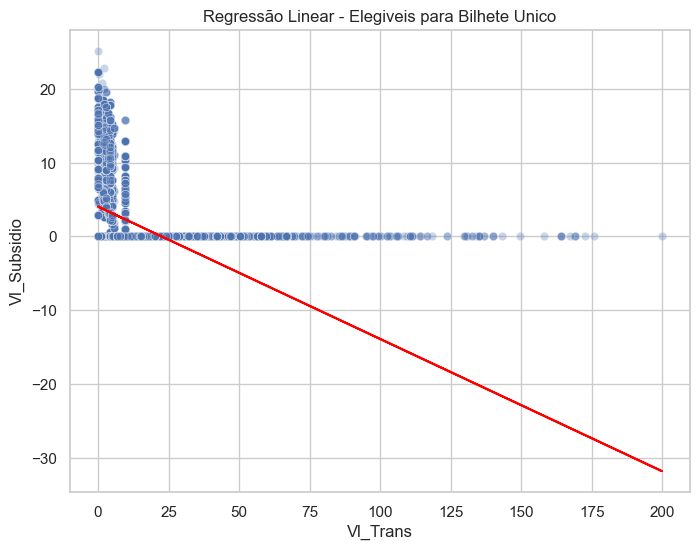

In [ ]:
def regressao_linear(df, nome):
 X = df[["Vl_Trans"]].fillna(0)
 y = df["Vl_Subsidio"].fillna(0)

 modelo = LinearRegression()
 modelo.fit(X, y)

 y_pred = modelo.predict(X)
 r2 = r2_score(y, y_pred)

 print(f"\n{'='*50}")
 print(f"REGRESSÃO - {nome}")
 print(f"{'='*50}")

 print("Coeficiente Angular:", modelo.coef_[0])
 print("Intercepto:", modelo.intercept_)
 print("R²:", r2)

 plt.figure(figsize=(8,6))

 sns.scatterplot(
  x=df["Vl_Trans"],
  y=df["Vl_Subsidio"],
  alpha=0.3
 )

 plt.plot(
  df["Vl_Trans"],
  y_pred,
  color="red"
 )

 plt.title(f"Regressão Linear - {nome}")
 plt.xlabel("Vl_Trans")
 plt.ylabel("Vl_Subsidio")
 plt.show()

regressao_linear(Bu_nao_elegiveis, "Não elegiveis para Bilhete Unico")
regressao_linear(Bu_elegiveis, "Elegiveis para Bilhete Unico")




Anotação:  a razão do coeficiente angular esta negativo 

Correlação Spearman para o grupo Não elegiveis para Bilhete Unico:


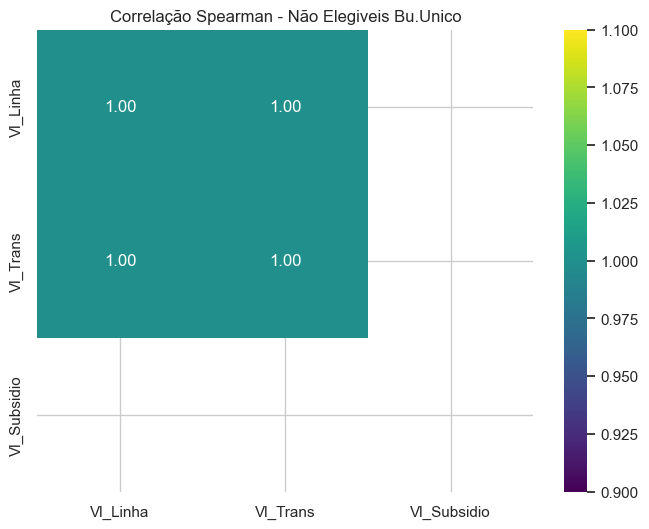

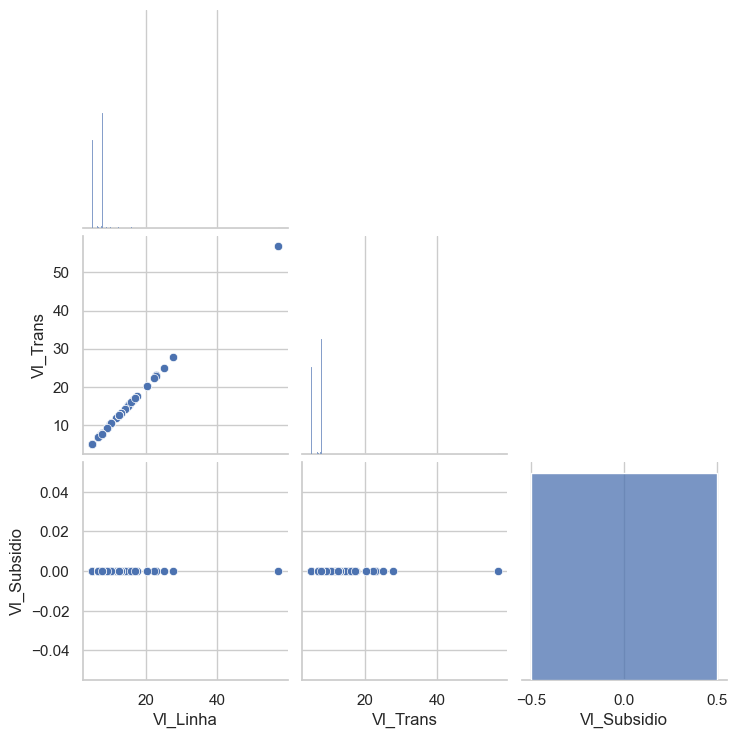

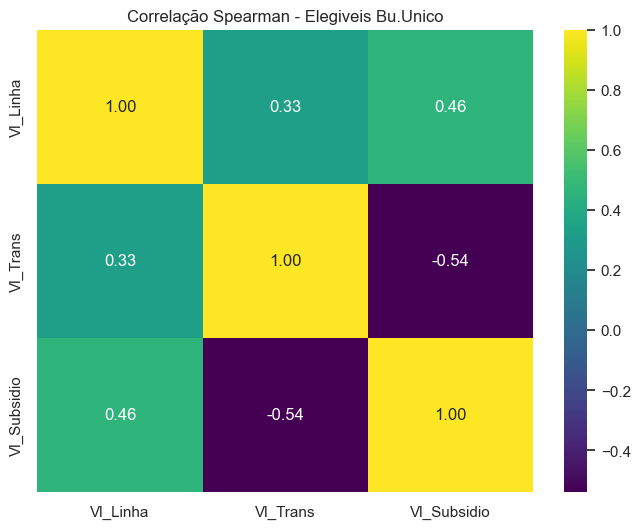

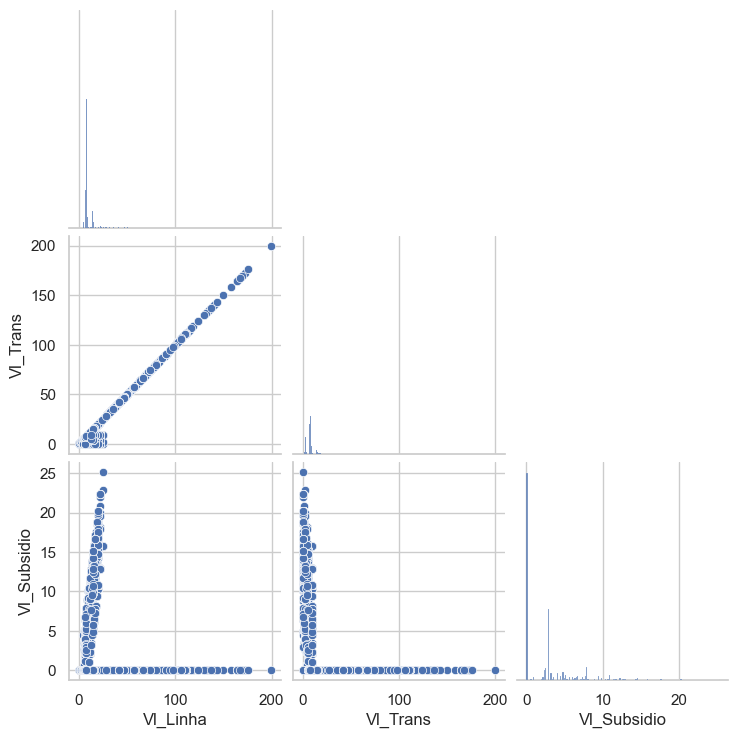

In [ ]:
print("Correlação Spearman para o grupo Não elegiveis para Bilhete Unico:")

def correlacao_spearman(df, nome):
 plt.figure(figsize=(8, 6))

 corr = df[[
  "Vl_Linha",
  "Vl_Trans",
  "Vl_Subsidio"
 ]].corr(method="spearman")

 sns.heatmap(
  corr,
  annot=True,
  cmap="viridis",
  fmt=".2f"
 )

 plt.title(f"Correlação Spearman - {nome}")
 plt.show()

 sns.pairplot(
  df[[
   "Vl_Linha",
   "Vl_Trans",
   "Vl_Subsidio"
  ]],
  corner=True
 )

plt.show()

correlacao_spearman(Bu_nao_elegiveis, "Não Elegiveis Bu.Unico")
correlacao_spearman(Bu_elegiveis, "Elegiveis Bu.Unico")

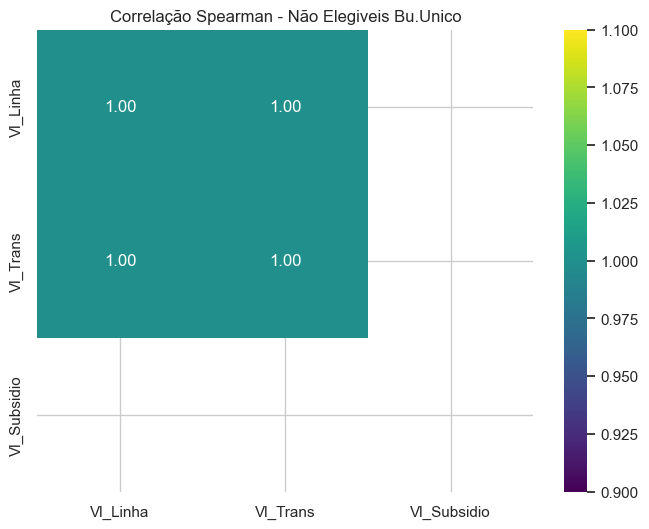

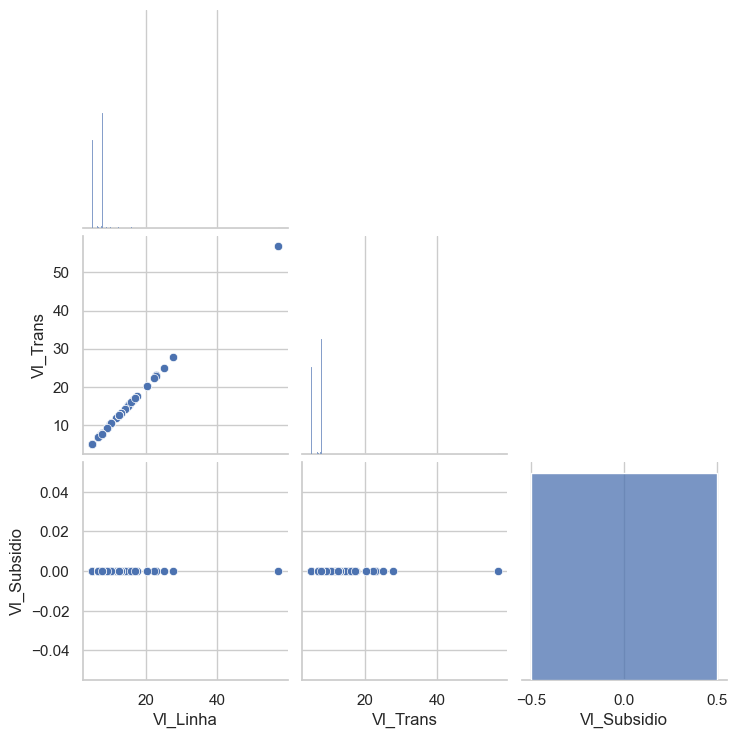

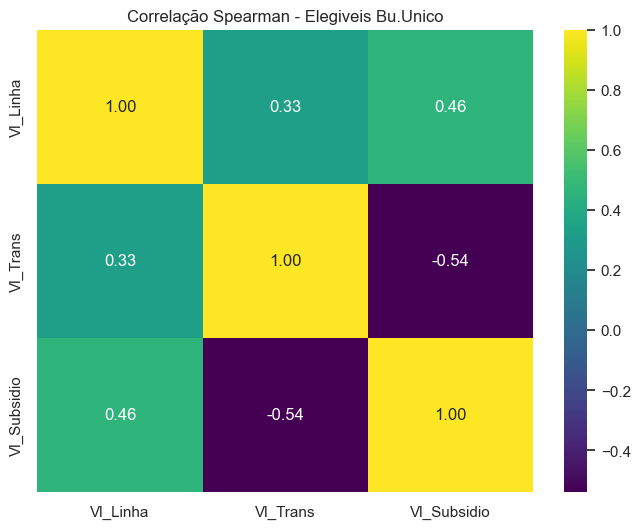

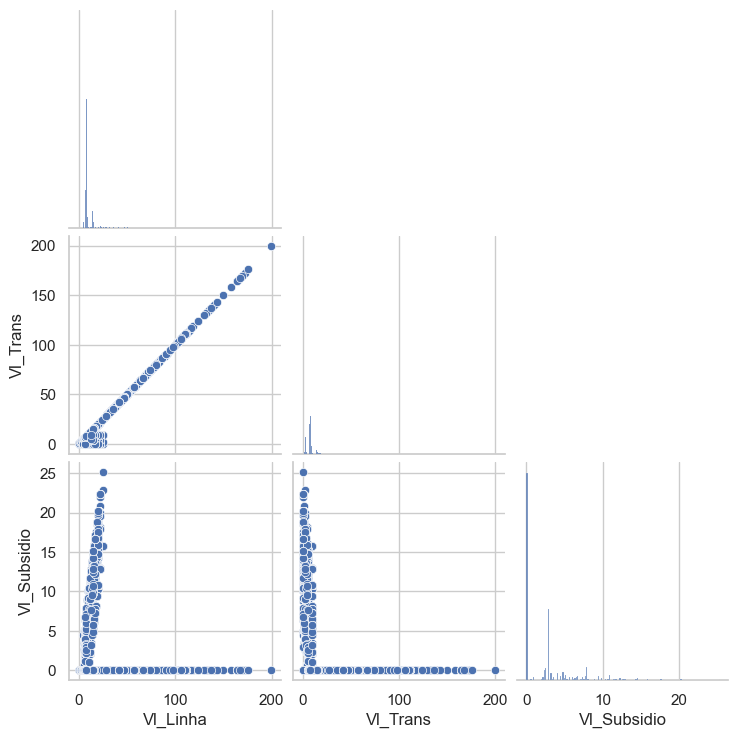

In [ ]:
def correlacao(df, nome):

 plt.figure(figsize=(8,6))

 sns.heatmap(
   df[[
  "Vl_Linha",
  "Vl_Trans",
  "Vl_Subsidio"
  ]].corr(),
  annot=True,
  map="coolwarm"
  )

 plt.title(f"Correlação - {nome}")

 plt.show()
correlacao_spearman(Bu_nao_elegiveis, "Não Elegiveis Bu.Unico")
correlacao_spearman(Bu_elegiveis, "Elegiveis Bu.Unico")

Anotações para apresentação do trabalho:


O dado mais importante está no Vl_Subsidio do grupo elegível. 
pois a distribuição assimétrica (muitos passageiros recebem subsídio baixo ou zero, poucos recebem subsídio alto) 
sugere que o benefício é concentrado em rotas específicas, provavelmente linhas mais longas ou de maior tarifa.

A regressão linear entre Vl_Trans e Vl_Subsidio no grupo elegível mostrar uma relação positiva: 
quanto maior o valor da passagem, maior tende a ser o subsídio, o Estado complementa mais em linhas mais caras.

Para os não elegíveis, essa regressão é estatisticamente irrelevante (R² ≈ 0), 
segundos os dados é a confirmação de que não existe relação entre o valor pago e subsídio nesse grupo, porque o subsídio simplesmente não existe.

Em resumo: meu projeto cobre as 4 exigências (Analise descritiva da base, Regressão linear simples, Distribuição de Frequência, Identificação de Outliers) 
a separação em dois grupos foi necessario pois a metodologia de tributação é diferente para os dois grupos, e os resultados mostram com clareza a assimetria entre os dois perfis de usuário do sistema de bilhetagem do Rio de Janeiro.